# IAD Pipeline
Anomaly detection pipeline using FiftyOne, Weights & Biases, and the IAD framework.

## 1. Environment Setup
Configure database URI and API keys.

In [1]:
import os
import sys
import warnings

# Set BEFORE any fiftyone imports
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost"
os.environ["WANDB_API_KEY"] = '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'


sys.path.append("..")

# Now safe to import
import wandb
import logging
from pathlib import Path
from src.manager import AnomalyDetectionManager as ADM

wandb.login()

/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
wandb: Currently logged in as: daniel-pommer (daniel-pommer-technische-hochschule-n-rnberg-georg-simon-ohm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 2. Configuration
Set your run parameters here before executing the pipeline.

In [2]:
tiling      = True
modelName   = "padim"
modelConfig = "padim"
modelTrainConfig = f"Training_{modelName}"
datasetName = "MVTecADShort"
split       = ("train","test")
category    = "bottle"
train       = True
evaluate    = True
datasetDir  = Path("../datasets/")
configDir   = Path("../configs/")
outputPath  = Path("../results/")
# ckptPath    = Path("../results/MVTecADShort/cable/padim/tiled/checkpoints")

## 3. Initialise Logger & IAD

In [3]:
logger = logging.getLogger("logger")

manager = ADM(configDir=configDir, datasetDir=datasetDir,outputPath=outputPath)

## 4. Load Dataset & Generate Model

In [4]:
manager.generateModel(f"{modelConfig}.yaml", configDir)
datasetPath = datasetDir/datasetName
manager.loadDatasetFromDisk(datasetPath, datasetName, overwrite=True, merge=False, split=split)
manager.selectCategory(category)
if manager.FO_Dataset is None:
    raise RuntimeError("Dataset failed to load — check your dataset path and name.")
if tiling:
    manager.setupTiling(configDir / "Tiling" / "TiledEnsemble.yaml")
manager.adjustOutputPath()
# manager.copyFilesToOutputPath()

INFO: Model Padim loaded: {'model': {'class_path': 'Padim', 'init_args': {'backbone': 'resnet18', 'layers': ['layer1', 'layer2', 'layer3'], 'pre_trained': True, 'n_features': 100, 'pre_processor': PreProcessor(), 'post_processor': AOIPostProcessor(
  (_image_threshold_metric): F1AdaptiveThreshold()
  (_pixel_threshold_metric): F1AdaptiveThreshold()
  (_image_min_max_metric): MinMax()
  (_pixel_min_max_metric): MinMax()
), 'visualizer': False, 'evaluator': Evaluator(
  (val_metrics): ModuleList(
    (0): AUROC()
  )
  (test_metrics): ModuleList(
    (0): AUROC()
    (1): F1Score()
    (2): AUPR()
  )
)}}}
INFO: Initializing Padim model.


/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'pre_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['pre_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'post_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['post_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'evaluator' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['evaluator'])`.


INFO: Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
INFO: [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO: Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
INFO: Model Padim(
  (pre_processor): PreProcessor()
  (post_processor): AOIPostProcessor(
    (_image_threshold_metric): F1AdaptiveThreshold()
    (_pixel_threshold_metric): F1AdaptiveThreshold()
    (_image_min_max_metric): MinMax()
    (_pixel_min_max_metric): MinMax()
  )
  (evaluator): Evaluator(
    (val_metrics): ModuleList(
      (0): AUROC()
    )
    (test_metrics): ModuleList(
      (0): AUROC()
      (1): F1Score()
      (2): AUPR()
    )
  )
  (model): PadimModel(
    (feature_extractor): TimmFeatureExtractor(
      (feature_extractor): FeatureListNet(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 

PosixPath('../results/MVTecADShort/bottle/Padim/tiled')

## 4.1 Inspect Dataset

In [ ]:
manager.launchSession()

Connected to FiftyOne on port 5151 at localhost.
If you are not connecting to a remote session, you may need to start a new session and specify a port
INFO: Connected to FiftyOne on port 5151 at localhost.
If you are not connecting to a remote session, you may need to start a new session and specify a port


INFO: DatasetView (category selection) currently not supported. Shown dataset is the entire dataset.
INFO: Session addess and port: localhost:5151



Could not connect session, trying again in 10 seconds



## 5. Training

In [6]:

warnings.filterwarnings("ignore", category=FutureWarning, module="timm.models.layers")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="openvino.runtime")
if train:
    manager.train(configDir / "Trainer" / Path(f"{modelTrainConfig}.yaml"), tiling=tiling)

INFO: Deleting MVTecADShort-bottle from database and reloading.
INFO: Setup tiling based on ../configs/Tiling/TiledEnsemble.yaml
INFO: Running job TrainModels


TrainModels: 0it [00:00, ?it/s]

INFO: Tiled ensemble training started. Separate models will be trained for 4 tile locations.
INFO: Initializing Padim model.
INFO: Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
INFO: [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO: Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
INFO: Loading the model.
INFO: Initializing Padim model.
INFO: Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)


/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'pre_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['pre_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'post_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['post_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'evaluator' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['evaluator'])`.


INFO: [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO: Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
INFO: Running <class 'src.tiling.tiled_ensemble.TrainModelJob'>
INFO: Training for tile at position (0, 0),


...

INFO: Job Threshold completed successfully.
INFO: Running job Visualize



Visualize: 0it [00:00, ?it/s]

INFO: Starting visualisation for Fiftyone.


51 Visualisation: 100%|██████████| 2/2 [00:00<00:00,  3.76it/s]
Visualize: 1it [00:00,  1.41it/s]

INFO: Job Visualize completed successfully.



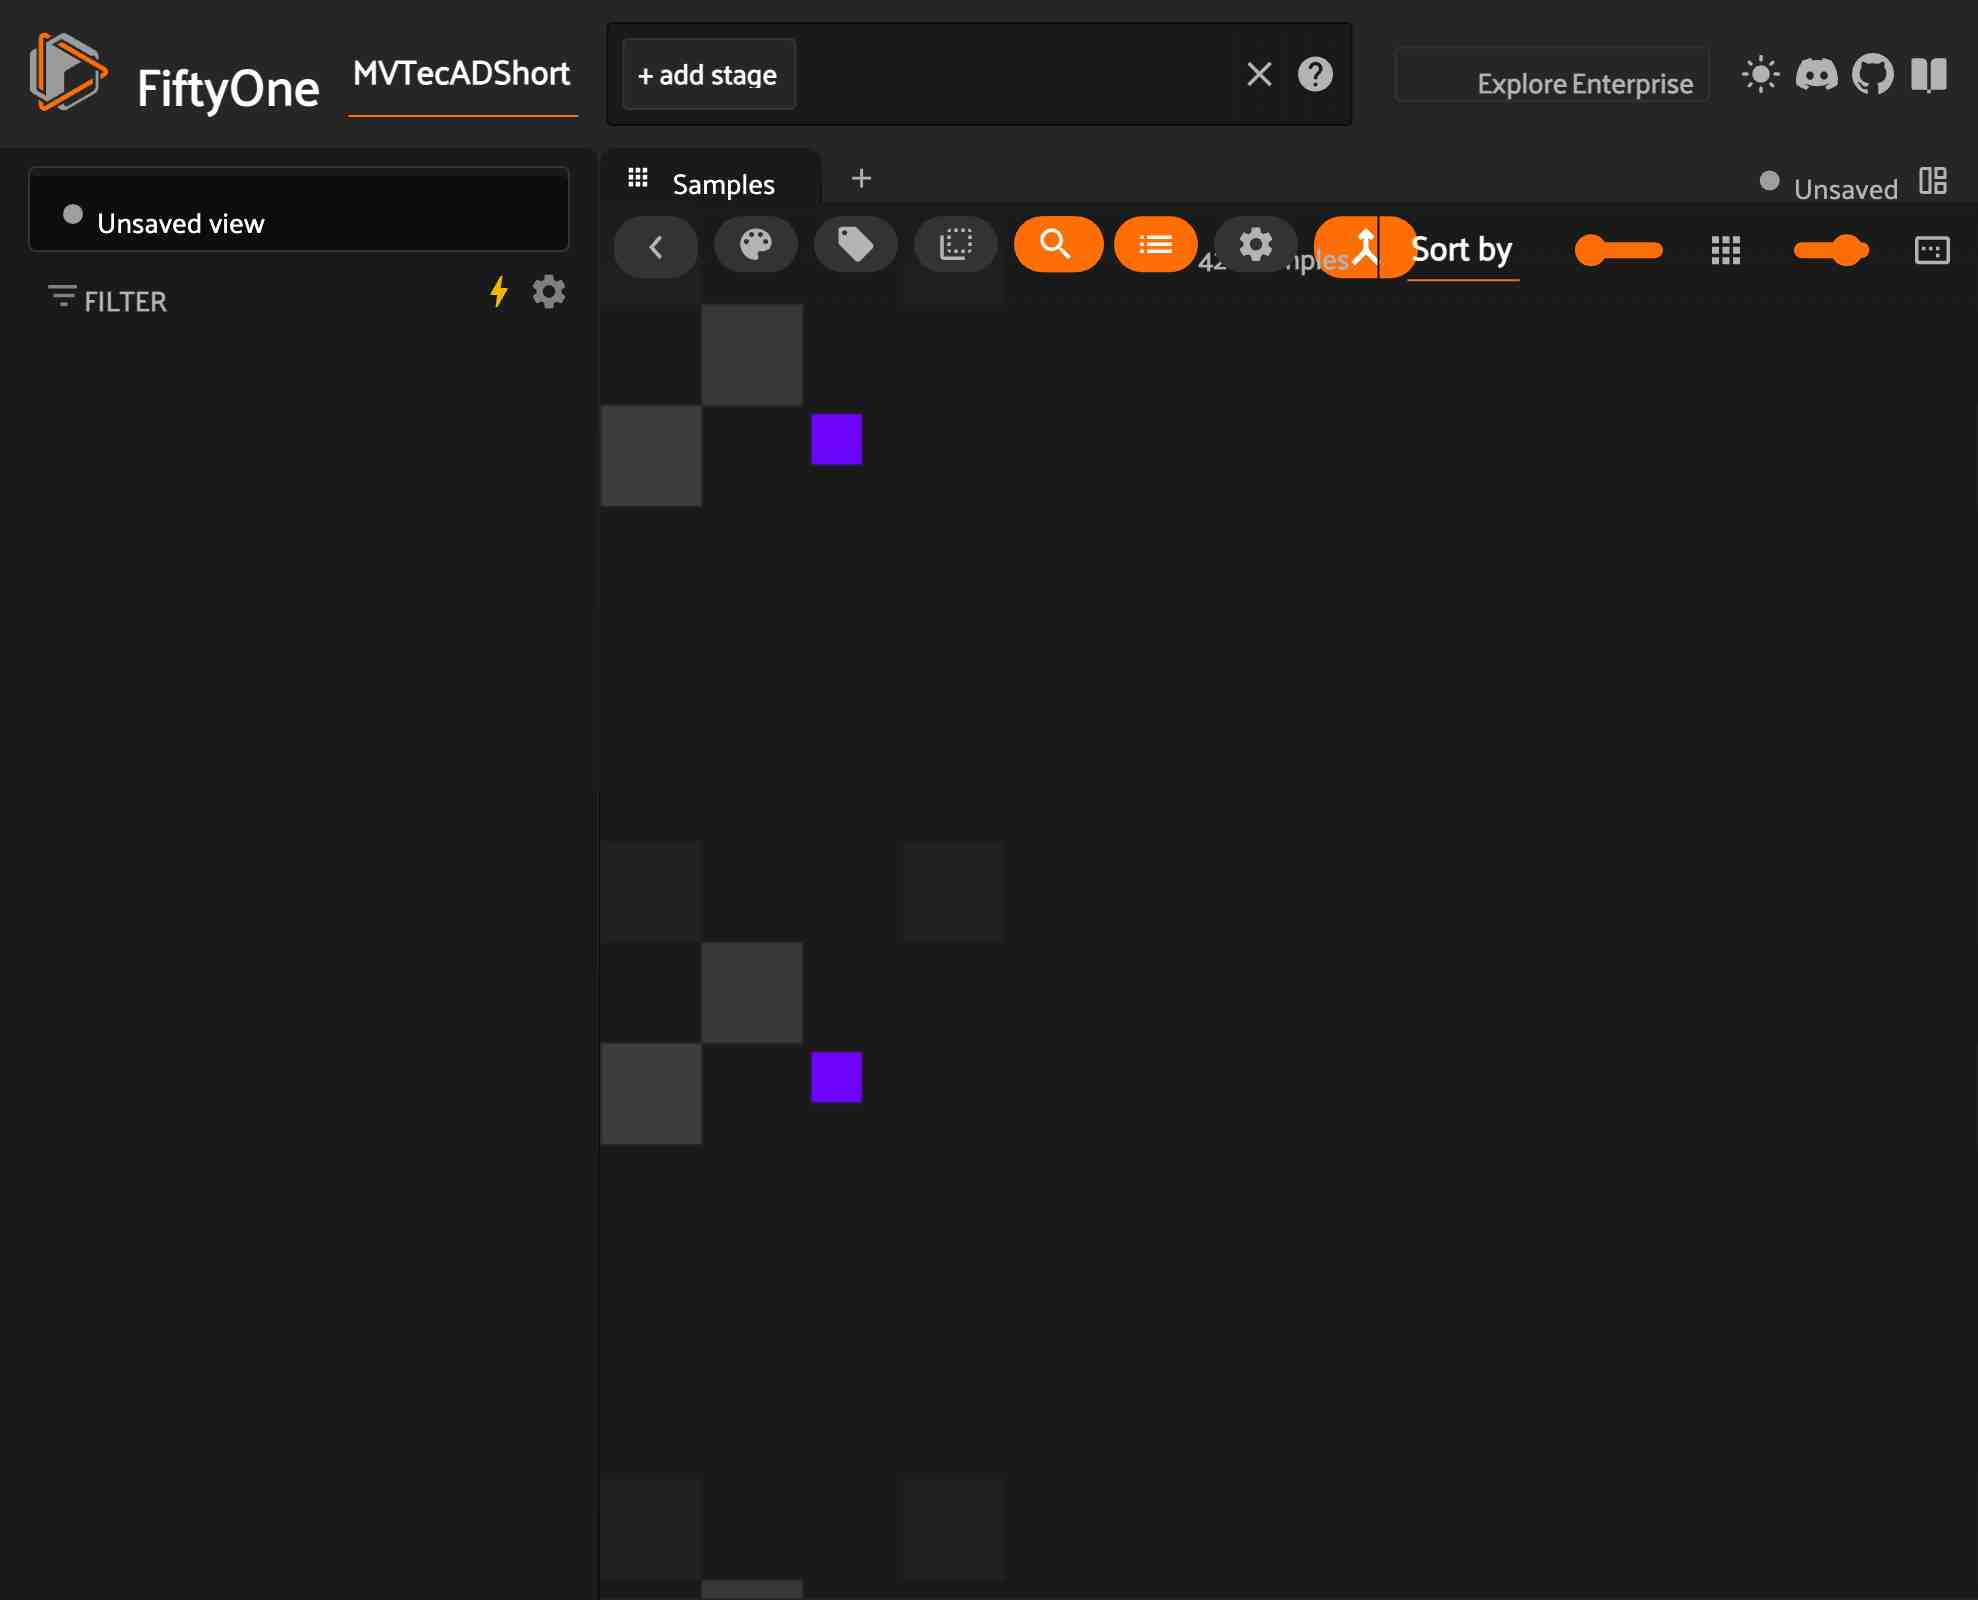

INFO: DatasetView (category selection) currently not supported. Shown dataset is the entire dataset.
INFO: Session addess and port: localhost:5151


In [7]:
manager.launchSession()

## 6. Evaluation & Prediction

In [8]:
# import time
# time.sleep(5)
# Database needs to load

if evaluate:
    if manager.ckptPath is not None:
        if not tiling:
            manager.loadCheckpoint(manager.ckptPath, f"{modelName}")
        manager.eval(configDir / "Trainer"/ "Evaluation.yaml", tiling=tiling)
        manager.launchSession()
    else:
        print("No checkpoint found — skipping evaluation.")
    

INFO: Running tiled ensemble evaluation pipeline.
INFO: Setup tiling based on ../configs/Tiling/TiledEnsemble.yaml
INFO: No ckptPath given in arguments to <class 'src.tiling.tiled_ensemble.EvalTiledEnsemble'>. Going over rootDir: ../results/MVTecADShort/bottle/Padim/tiled/checkpoints
INFO: Taking stats for Nomalization from: ../results/MVTecADShort/bottle/Padim/tiled
INFO: Taking stats for Thresholding from: ../results/MVTecADShort/bottle/Padim/tiled
INFO: Running job Predict


Predict: 0it [00:00, ?it/s]

INFO: Tiled ensemble predicting started using Using ckpt_pathtest data.
INFO: Initializing Padim model.
INFO: Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
INFO: [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO: Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
INFO: Loading the model.
INFO: Initializing Padim model.


/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'pre_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['pre_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'post_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['post_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'evaluator' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['evaluator'])`.


INFO: Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
INFO: [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO: Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
INFO: Loading checkpoint from ckpt_path: ../results/MVTecADShort/bottle/Padim/tiled/checkpoints/model0_0.ckpt. No Model from previous training job available.
INFO: Start of predicting for tile at position (0, 0),


...


Metrics: 0it [00:00, ?it/s]

INFO: Initializing Padim model.
INFO: Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
INFO: [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO: Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
INFO: Loading the model.
INFO: Initializing Padim model.
INFO: Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
INFO: [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO: Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
INFO: Starting Metrics!.


Calculating metrics: 100%|██████████| 2/2 [00:00<00:00, 450.13it/s]
Metrics: 1it [00:01,  1.28s/it]

image_AUROC: 0.5000
image_F1Score: 0.6667
image_AUPR: 0.7500
INFO: Saving metrics to csv.
INFO: Job Metrics completed successfully.


INFO: DatasetView (category selection) currently not supported. Shown dataset is the entire dataset.
INFO: Session addess and port: localhost:5151


## 7. Evaluate on single unknown Image

In [9]:
# ckptPath = manager.ckptPath.parent.resolve()
# print(ckptPath)

In [ ]:

# # ckptPath = manager.ckptPath.parent.resolve()
# # print(ckptPath)
# manager.loadDatasetFromDisk(datasetPath=datasetDir / "MVTecADShortPred", datasetName="cablePred36", split=("pred",), overwrite=True)
# # manager.selectCategory("cable")

# if manager.ckptPath is not None:
#     if not tiling:
#         manager.loadCheckpoint(manager.ckptPath, f"{modelName}")
#     if tiling:
#         manager.setupTiling(configDir / "TiledEnsemblePred.yaml")
#     manager.predict(config=configDir / "Predict.yaml", tiling=tiling, ckptPath=ckptPath)
#     print(manager.FO_Dataset)
#     manager.launchSession()
#     print(manager.FO_Dataset)
#     manager.launchSession()